In [12]:
suppressMessages({
library(BayesSpace)
library(SingleCellExperiment)
library(ggplot2)
library(Seurat)
library(cowplot)
library(RColorBrewer)
library(getopt)
library(ComplexHeatmap)
library(viridis)
library(future)
library(dplyr)
library(Matrix)
library(data.table)
library(reshape2)
})
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
cols = c(cols,cols)
##############################################################
# set.seed(123)


### MPPED1 donor-level Exp

In [1]:
suppressMessages({
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
})

Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”


In [97]:
seuobj = readRDS('/data/work/08.脑区划分/02.result/01.bin100/bin.AD_all32chips.250224.adj_xy.rds')

In [102]:
seuobj@meta.data[1,]
table(seuobj$area)

,orig.ident,nCount_RNA,nFeature_RNA,sample,coor_y,coor_x,label,area
,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>
Con1.1_Con1.1_BIN100_357_1,Con1.1,2588,640,Con1.1,611,0,Con1.1_0_611,Others



CA1_Sub  Others 
 192726  557087 

In [103]:
seuobj$area[which(seuobj$area %in% c('CA1','Sub') )] = 'CA1_Sub'
table(seuobj$area)


CA1_Sub  Others 
 192726  557087 

In [104]:
seuobj$area <- ifelse(seuobj$area == "CA1_Sub", "CA1_Sub", "Others")
table(seuobj$area)


CA1_Sub  Others 
 192726  557087 

In [105]:
table(seuobj$sample)


 AD1.1  AD1.2  AD2.1  AD2.2  AD3.1  AD3.2  AD4.1  AD4.2  AD5.1  AD5.2  AD6.1 
 13286  16064  30947  30845  17318  16746  21983  20339  28148  28888  32514 
 AD6.2  AD7.1  AD7.2  AD8.1  AD8.2 Con1.1 Con1.2 Con2.1 Con2.2 Con3.1 Con3.2 
 29286  28400  26854  31860  30890  30532  29587  23236  23639  27106  27294 
Con4.1 Con4.2 Con5.1 Con5.2 Con6.1 Con6.2 Con7.1 Con7.2 Con8.1 Con8.2 
 24598  24277  31649  33008  26832  29777  31648  29834  27468  28773 

In [106]:
seuobj$group = 'Con'
seuobj$group[which( grepl('AD',seuobj$sample)==TRUE )] = 'AD'

sample_need = c('Con1.1','Con1.2','Con2.1','Con2.2','Con3.1','Con3.2','Con5.1','Con5.2','Con6.1','Con6.2','Con8.1','Con8.2',
'AD2.1','AD2.2','AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD7.1','AD7.2','AD8.1','AD8.2')

seuobj = subset(seuobj,sample %in%  sample_need )

In [23]:
# ### 只包含CA1和Sub脑区的rds
# seuobj_all = readRDS('/data/work/08.脑区划分/02.result/01.bin100/bin.AD_all32chips.CA1_Sub.250217.rds')

# seuobj_all$group = 'Con'
# seuobj_all$group[which( grepl('AD',seuobj_all$sample)==TRUE )] = 'AD'

# sample_need = c('Con1.1','Con1.2','Con2.1','Con2.2','Con3.1','Con3.2','Con5.1','Con5.2','Con6.1','Con6.2','Con8.1','Con8.2',
# 'AD2.1','AD2.2','AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD7.1','AD7.2','AD8.1','AD8.2')

# seuobj = subset(seuobj_all,sample %in%  sample_need )

In [107]:
table(seuobj$sample)
table(seuobj$area)
table(seuobj$group)


 AD2.1  AD2.2  AD4.1  AD4.2  AD5.1  AD5.2  AD6.1  AD6.2  AD7.1  AD7.2  AD8.1 
 30947  30845  21983  20339  28148  28888  32514  29286  28400  26854  31860 
 AD8.2 Con1.1 Con1.2 Con2.1 Con2.2 Con3.1 Con3.2 Con5.1 Con5.2 Con6.1 Con6.2 
 30890  30532  29587  23236  23639  27106  27294  31649  33008  26832  29777 
Con8.1 Con8.2 
 27468  28773 


CA1_Sub  Others 
 157046  418996 


    AD    Con 
340954 338901 

In [108]:
gene_use <- "MPPED1"

sample_col <- "sample"
region_col <- "area"
group_col  <- "group"

# Fig.1b 中 CA1 对比的其他脑区
other_regions <- 'Others'

# 如果你的 metadata 中 CA2-4 写法不同，比如 CA2_4 或 CA2–4，需要改这里

In [109]:
unique(seuobj@meta.data[[region_col]])
seuobj$area[which(is.na(seuobj$area)==TRUE)] = 'Others'
unique(seuobj@meta.data[[region_col]])

[1] "Others"  "CA1_Sub" NA

[1] "Others"  "CA1_Sub"

In [110]:
df <- FetchData(
  seuobj,
  vars = c(gene_use, sample_col, region_col, group_col),
  slot = "data"
)

colnames(df) <- c("expr", "sample_id", "region", "group")

df <- df %>%
  filter(region %in% c("CA1_Sub", other_regions)) %>%
  filter(group %in% c("AD", "Con"))

In [111]:
df[1:3,]

,expr,sample_id,region,group
,<dbl>,<chr>,<chr>,<chr>
Con1.1_Con1.1_BIN100_357_1,0,Con1.1,Others,Con
Con1.1_Con1.1_BIN100_358_1,0,Con1.1,Others,Con
Con1.1_Con1.1_BIN100_359_1,0,Con1.1,Others,Con


In [112]:
donor_region_expr <- df %>%
  mutate(region_group = ifelse(region == "CA1_Sub", "CA1_Sub", "Other")) %>%
  group_by(group, sample_id, region_group) %>%
  summarise(
    mean_expr = mean(expr, na.rm = TRUE),
    n_bins_or_cells = n(),
    .groups = "drop"
  )

print(donor_region_expr)

# A tibble: 48 × 5
   group sample_id region_group mean_expr n_bins_or_cells
   <chr> <chr>     <chr>            <dbl>           <int>
 1 AD    AD2.1     CA1_Sub         0.848             6211
 2 AD    AD2.1     Other           0.181            24736
 3 AD    AD2.2     CA1_Sub         1.27              5224
 4 AD    AD2.2     Other           0.274            25621
 5 AD    AD4.1     CA1_Sub         0.280             6829
 6 AD    AD4.1     Other           0.0843           15154
 7 AD    AD4.2     CA1_Sub         0.264             5993
 8 AD    AD4.2     Other           0.0885           14346
 9 AD    AD5.1     CA1_Sub         0.873             5581
10 AD    AD5.1     Other           0.189            22567
# ℹ 38 more rows


In [113]:
###整理成宽表
wide_expr <- donor_region_expr %>%
  select(group, sample_id, region_group, mean_expr) %>%
  pivot_wider(
    names_from = region_group,
    values_from = mean_expr
  ) %>%
  filter(!is.na(CA1_Sub), !is.na(Other))

print(wide_expr)

# A tibble: 24 × 4
   group sample_id CA1_Sub  Other
   <chr> <chr>       <dbl>  <dbl>
 1 AD    AD2.1       0.848 0.181 
 2 AD    AD2.2       1.27  0.274 
 3 AD    AD4.1       0.280 0.0843
 4 AD    AD4.2       0.264 0.0885
 5 AD    AD5.1       0.873 0.189 
 6 AD    AD5.2       1.04  0.271 
 7 AD    AD6.1       0.509 0.137 
 8 AD    AD6.2       0.713 0.203 
 9 AD    AD7.1       1.10  0.236 
10 AD    AD7.2       0.771 0.172 
# ℹ 14 more rows


In [ ]:
###分别在AD和Con中检验
stat_CA1Sub_vs_Other <- wide_expr %>%
  group_by(group) %>%
  group_modify(~ {
    test <- t.test(.x$CA1_Sub, .x$Other, paired = TRUE)
    
    data.frame(
      gene = gene_use,
      comparison = "CA1Sub_vs_Other",
      test = "paired_t_test",
      n_donors = nrow(.x),
      mean_CA1 = mean(.x$CA1_Sub, na.rm = TRUE),
      mean_Other = mean(.x$Other, na.rm = TRUE),
      mean_difference_CA1Sub_minus_Other = mean(.x$CA1_Sub - .x$Other, na.rm = TRUE),
      t_statistic = unname(test$statistic),
      p_value = test$p.value
    )
  }) %>%
  ungroup() %>%
  mutate(
    p_adj_Holm = p.adjust(p_value, method = "holm")
  )

stat_CA1Sub_vs_Other

write.csv(
  stat_CA1Sub_vs_Other,
  file = "Fig1b_MPPED1_CA1Sub_vs_Other_AD_Con_donor_level.csv",
  row.names = FALSE
)

In [17]:
stat_CA1Sub_vs_Other

group,gene,comparison,test,n_donors,mean_CA1,mean_Other,mean_difference_CA1Sub_minus_Other,t_statistic,p_value,p_adj_Holm
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AD,MPPED1,CA1Sub_vs_Other,paired_t_test,12,0.8299205,0.2032602,0.6266603,7.977833,6.706786e-06,1.341357e-05
Con,MPPED1,CA1Sub_vs_Other,paired_t_test,12,0.9726955,0.2539495,0.7187460,6.611742,3.802826e-05,3.802826e-05


In [18]:
donor_region_expr[1:3,]

group,sample_id,region_group,mean_expr,n_bins_or_cells
<chr>,<chr>,<chr>,<dbl>,<int>
AD,AD2.1,CA1_Sub,0.8476896,6211
AD,AD2.1,Other,0.1806679,24736
AD,AD2.2,CA1_Sub,1.2720138,5224


In [27]:
df[c(1:3,208000),]

,expr,sample_id,region,group
,<dbl>,<chr>,<chr>,<chr>
Con1.1_Con1.1_BIN100_357_1,0,Con1.1,Others,Con
Con1.1_Con1.1_BIN100_358_1,0,Con1.1,Others,Con
Con1.1_Con1.1_BIN100_359_1,0,Con1.1,Others,Con
Con8.2_BIN100_23533_1,0,Con8.2,Others,Con


In [30]:
df$donor = gsub('\\..*$','',df$sample_id)
table(df$donor)


  AD2   AD4   AD5   AD6   AD7   AD8  Con1  Con2  Con3  Con5  Con6  Con8 
61792 42322 57036 61800 55254 62750 60119 46875 54400 64657 56609 56241 

In [33]:
# 汇总为donor-level
donor_expr <- df %>%
  dplyr::filter(!is.na(expr)) %>%
  dplyr::group_by(
    donor,
    group,
    region
  ) %>%
  dplyr::summarise(
    donor_mean_expr = mean(expr, na.rm = TRUE),
    n_bins = dplyr::n(),
    .groups = "drop"
  )

# donor_expr

# 计算MEAN和SEM
expr_summary <- donor_expr %>%
  dplyr::group_by(region, group) %>%
  dplyr::summarise(
    n_donor = dplyr::n_distinct(donor),
    mean_expr = mean(donor_mean_expr, na.rm = TRUE),
    sd_expr = stats::sd(donor_mean_expr, na.rm = TRUE),
    sem_expr = sd_expr / sqrt(n_donor),
    .groups = "drop"
  )

expr_summary

region,group,n_donor,mean_expr,sd_expr,sem_expr
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
CA1_Sub,AD,6,0.8279623,0.32666705,0.13336126
CA1_Sub,Con,6,0.9720937,0.40930777,0.16709920
Others,AD,6,0.2034089,0.07231315,0.02952172
Others,Con,6,0.2537993,0.09729585,0.03972086


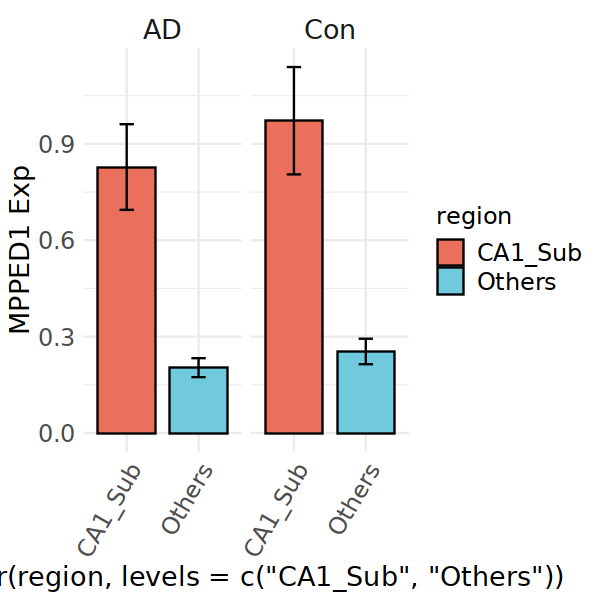

In [36]:
p = ggplot( expr_summary , aes(x = factor(region, levels = c('CA1_Sub','Others') ),  
                            y = mean_expr, fill = region)) +  
  geom_bar(stat = "identity", width = 0.8, color = "black") +  
  geom_errorbar(aes(ymin = mean_expr - sem_expr, ymax = mean_expr + sem_expr),  
                width = 0.2, color = "black") +  
  scale_fill_manual(values =  c("CA1_Sub" = "#EA6F5D", "Others" = "#70C9DD")  ) +  
  theme_minimal() +  
  theme(axis.text.x = element_text(hjust = 1,angle = 60,size = 14),  
        axis.text.y = element_text(size = 14),  
        legend.title = element_text(size = 14),  
        legend.text = element_text(size = 14),  
        axis.title = element_text(size = 16),
       strip.text = element_text(size = 16)) +  
  ylab("MPPED1 Exp")+    
  facet_wrap(~group)
options(repr.plot.width = 5,repr.plot.height = 5)
p
ggsave('Fig1b_MPPED1.CA1Sub_vs_Other_AD_Con_donor.pdf',p,width = 5,height = 5)

### FeaturePlot & BayesSpace

In [28]:
alldata = readRDS('/data/users/heyouzhe/online/CA1_Sub_32chips.rds')

In [ ]:
# seu_subset = subset(seuobj,area_m %in% c('CA1','Sub') )
DefaultAssay(alldata) = 'RNA'
alldata@meta.data$row = alldata@meta.data$coor_y
alldata@meta.data$col = alldata@meta.data$coor_x
date()

sce <- as.SingleCellExperiment(alldata)
sce <- spatialPreprocess(sce, platform="ST", 
                     n.PCs=30, n.HVGs=3000, log.normalize=F)
date()

[1] "Tue Nov  4 09:47:58 2025"

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.7 GiB”


In [ ]:
n_clu=5
set.seed(158331)

sce <- spatialCluster(sce, q=n_clu,
                      use.dimred = 'HARMONY',
                      platform="ST", 
                      d=30,
                      init.method="mclust",
                      model="t",
                      gamma=2,
                      nrep=100, 
                      burn.in=10, 
                      save.chain=TRUE)

In [97]:
meta = colData(sce)
meta = meta[as.matrix(rownames(alldata@meta.data)),]
alldata@meta.data[,paste0("BayesSpace.clu",n_clu)] = factor(meta$spatial.cluster,levels = 1:n_clu)
Idents(alldata) = paste0("BayesSpace.clu",n_clu)
# saveRDS(meta,paste0('CA1_Sub.af_harmony.bin100_bayes',n_clu,'.rds'))

Warning message in NSBS(i, x, exact = exact, strict.upper.bound = !allow.append, :
“subscript is an array, passing it thru as.vector() first”


In [30]:
meta = readRDS('/data/users/heyouzhe/online/Region-division/01_result/CA1_Sub.af_harmony.bin100_bayes5.rds')
alldata$BayesSpace.clu5 = meta$spatial.cluster[match(row.names(alldata@meta.data),row.names(meta) )]
# alldata@meta.data[,paste0("BayesSpace.clu",n_clu)] = factor(meta$spatial.cluster,levels = 1:n_clu)


In [31]:
alldata = subset(alldata,BayesSpace.clu5 %in% c(1,2,3,4,5))

In [22]:
alldata@meta.data[alldata@meta.data$sample%in%c('Con5.1','Con5.2','Con6.1','Con6.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('Con5.1','Con5.2','Con6.1','Con6.2'),]$coor_x-500
alldata@meta.data[alldata@meta.data$sample%in%c('Con8.1','Con8.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('Con8.1','Con8.2'),]$coor_x-1100
alldata@meta.data[alldata@meta.data$sample%in%c('AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD8.1','AD8.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD8.1','AD8.2'),]$coor_x-1100
alldata@meta.data[alldata@meta.data$sample%in%c('AD7.1','AD7.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD7.1','AD7.2'),]$coor_x-1000
alldata@meta.data[alldata@meta.data$sample%in%c('AD2.1','AD2.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD2.1','AD2.2'),]$coor_x-500

In [32]:
alldata$BayesSpace.clu5 = factor(alldata$BayesSpace.clu5)
class(alldata$BayesSpace.clu5)

[1] "factor"

In [ ]:
colors_use <- viridis(10, direction = 1, option = "H")
# options(repr.plot.width = 3, repr.plot.height = 3)
    
plasma <- viridis::viridis(10, direction = 1, option = "C")
coord <- data.frame(stereo_1 = alldata$coor_x, stereo_2 = alldata$coor_y)
alldata[["stereo"]] <- SeuratObject::CreateDimReducObject(embeddings = as.matrix(coord), key = "stereo_", assay = "RNA")

p1 = FeaturePlot( alldata , features = 'MPPED1' ,reduction = "stereo",pt.size = 0.00001,raster=FALSE)+
scale_colour_gradientn(colours = colors_use,limits = c(0,6))+
theme(axis.line = element_blank(), axis.text = element_blank(), axis.ticks = element_blank(), axis.title = element_blank())+coord_fixed()#+

p1

[1] 5

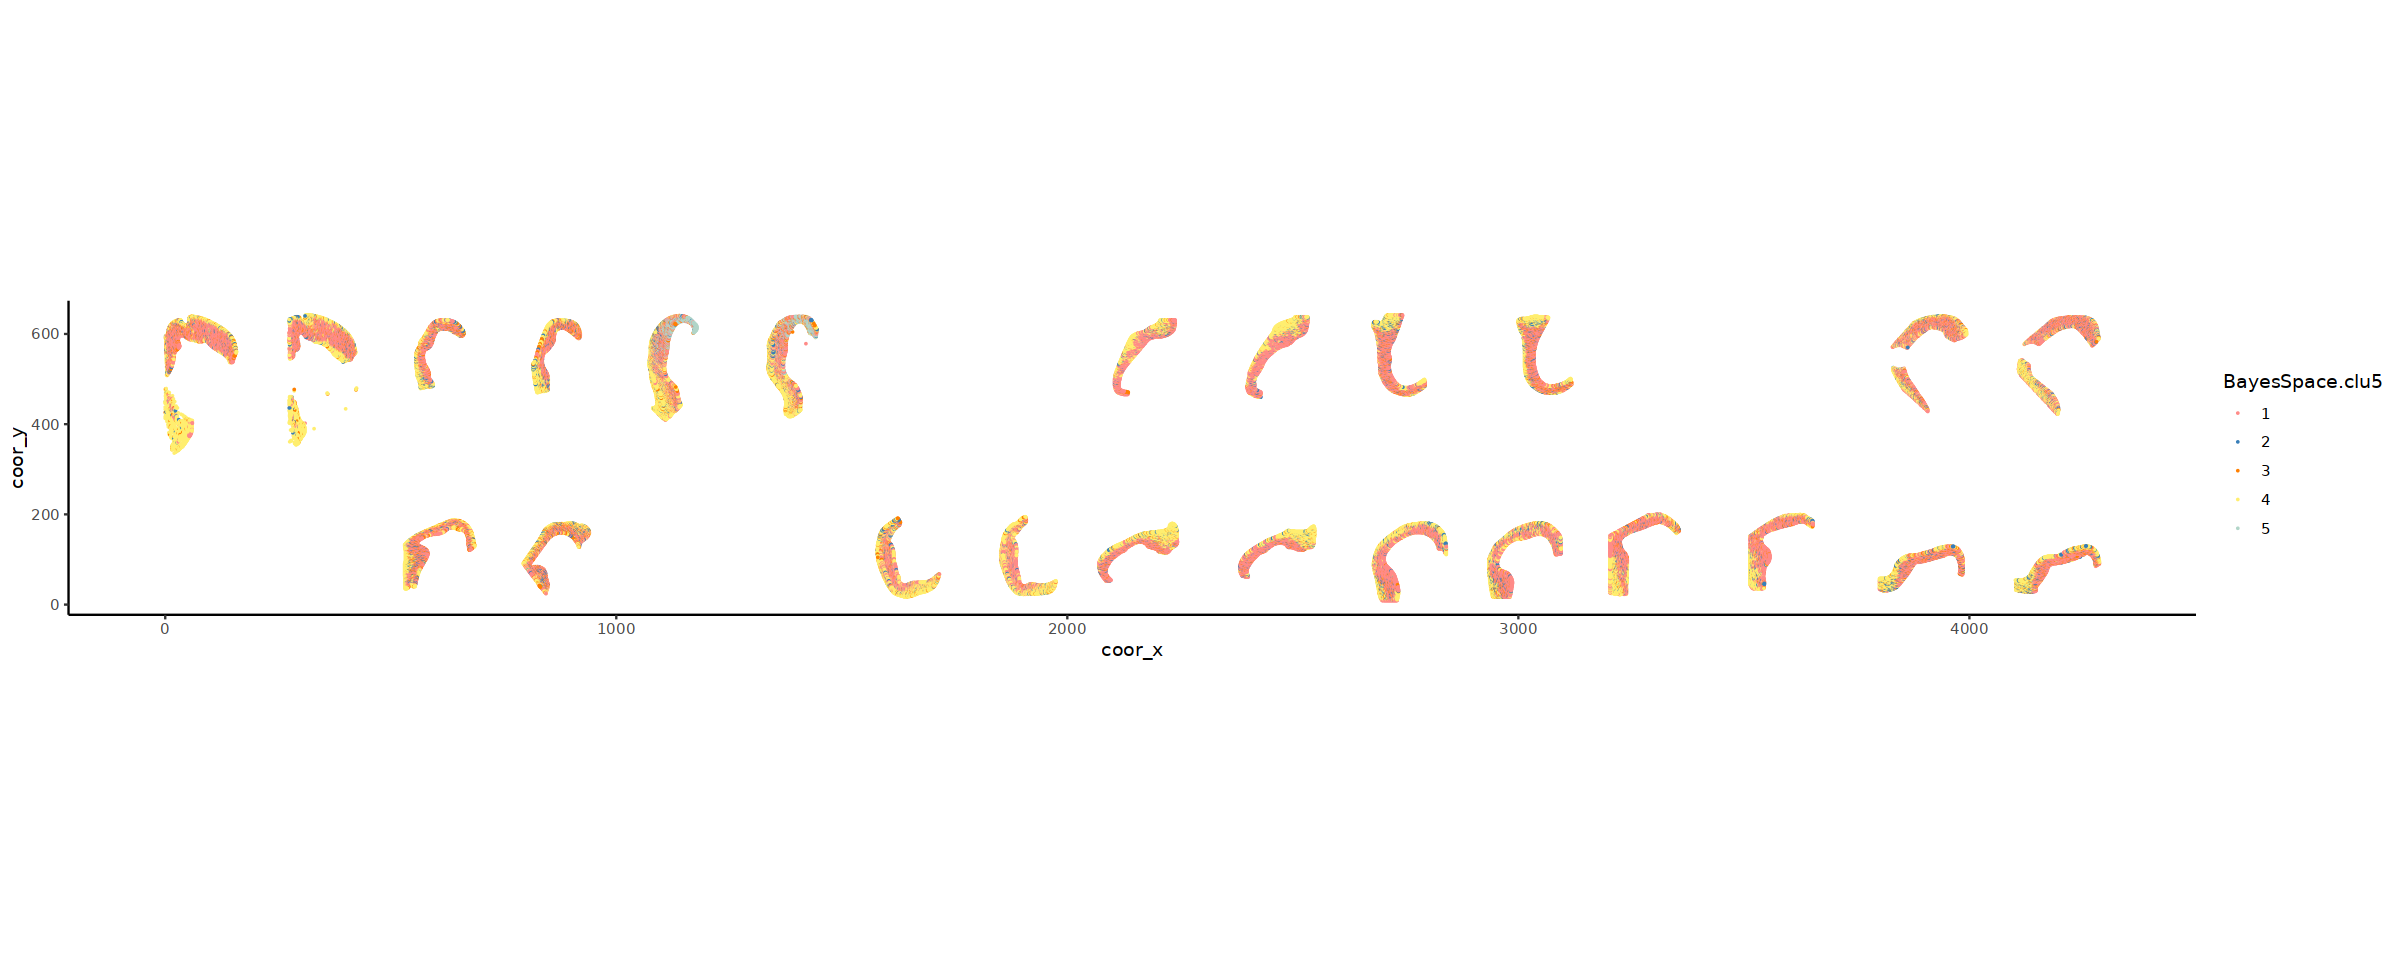

In [33]:
n_clu
ggplot(alldata@meta.data,aes(x = coor_x, y = coor_y, color = BayesSpace.clu5))+
geom_point(size = 0.001) +
scale_color_manual(values = cols) + 
theme_classic()+ coord_fixed()+ 
scale_fill_manual(values =cols)+
labs(fill=alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],x = "coor_x",y = "coor_y")+guides(fill=guide_legend(title=paste0("BayesSpace.clu",n_clu)))


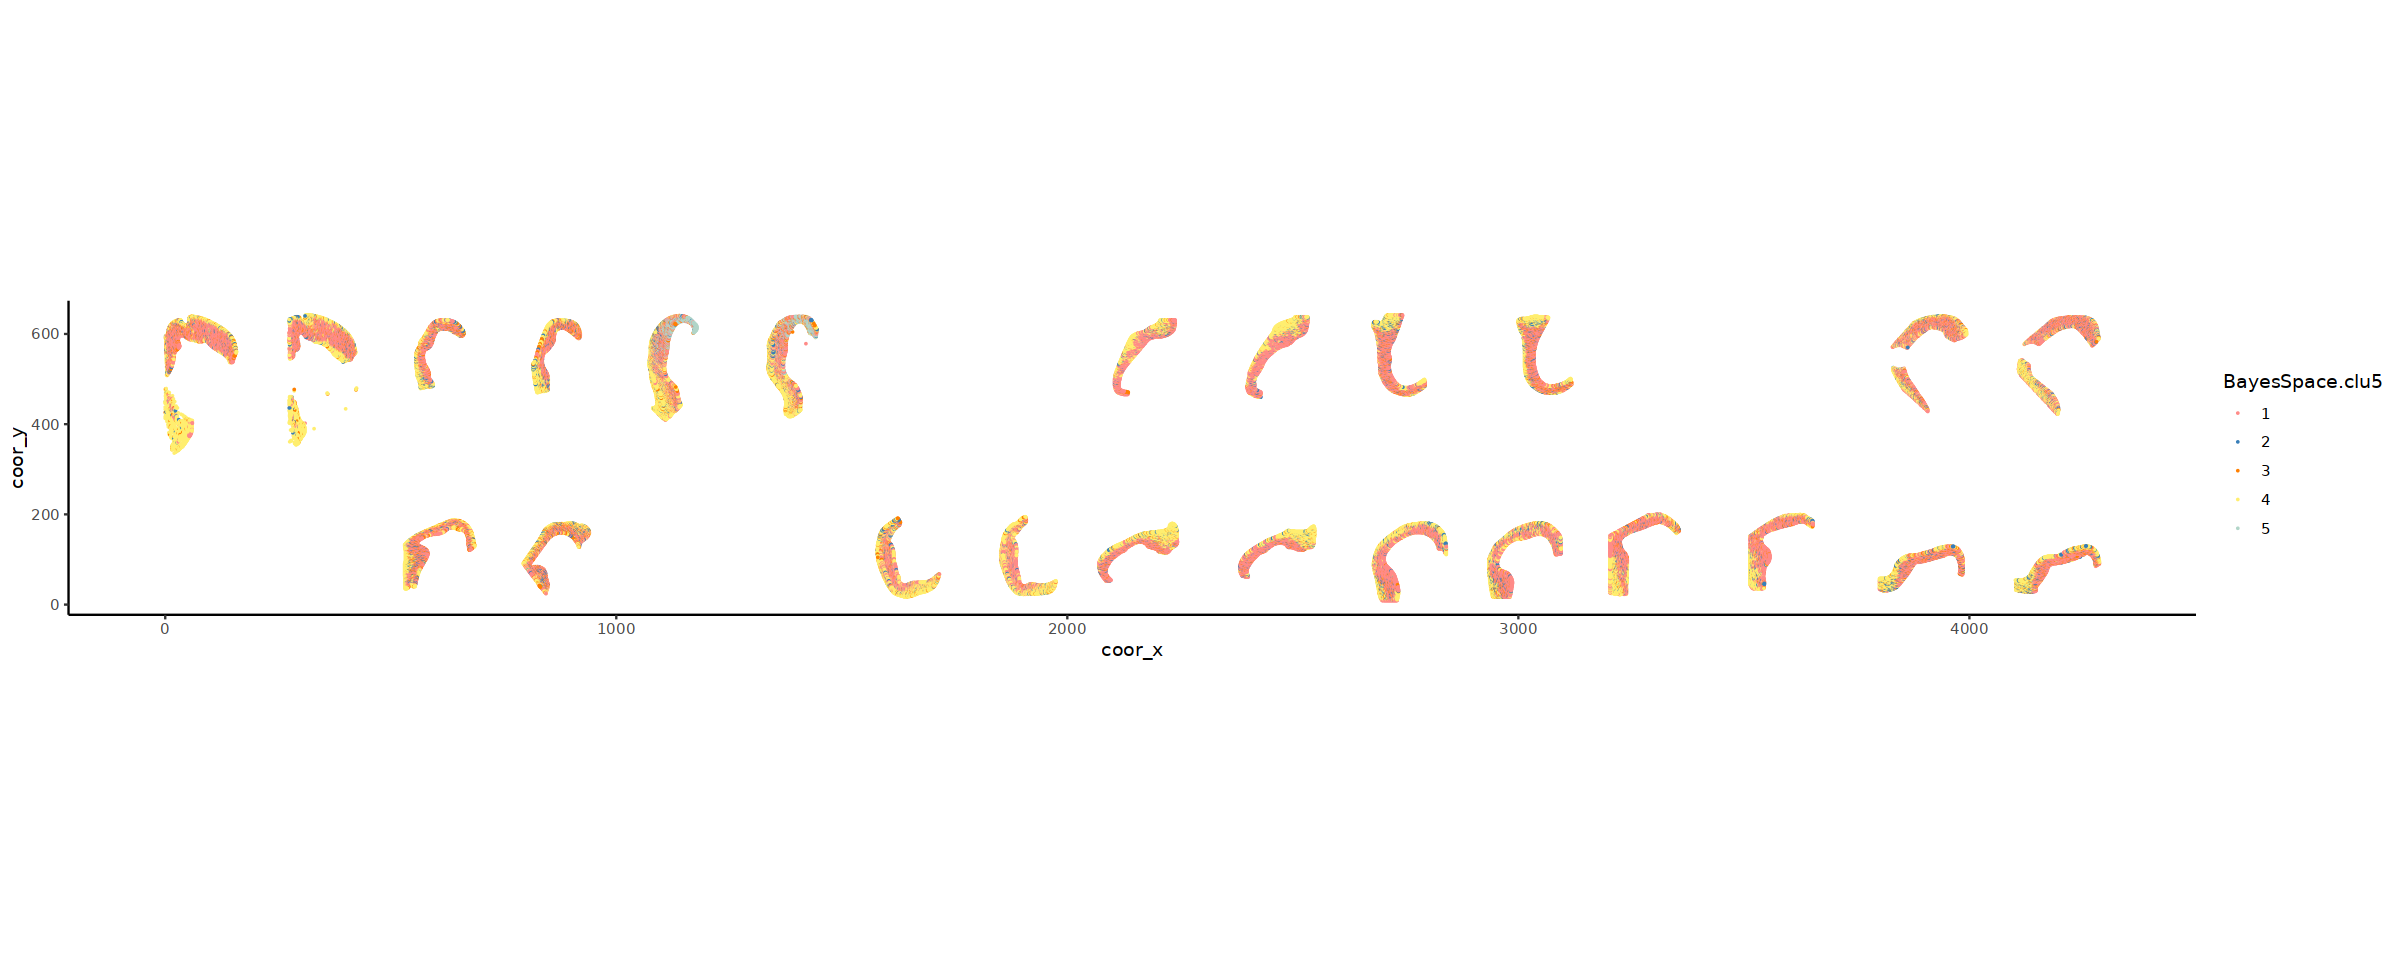

In [34]:
options(repr.plot.width = 20, repr.plot.height = 8)
#######plot bayesSpace clusters
# p <-  ggplot(alldata@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= alldata@meta.data[,paste0("BayesSpace.clu",n_clu)]))+geom_tile() + theme_classic()+ coord_fixed()+ scale_fill_manual(values =cols)+
# labs(fill=alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],x = "coor_x",y = "coor_y")+facet_wrap(. ~ alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],ncol = 5)+guides(fill=guide_legend(title=paste0("BayesSpace.clu",n_clu)))
# p
cols = c('#FF8B88','#377EB8','#FF7F00','#ffee6f','#b1d5c8')
#######plot bayesSpace clusters
n_clu = 5
p1 <-  ggplot(alldata@meta.data,aes(x = coor_x, y = coor_y, color = BayesSpace.clu5))+
geom_point(size = 0.001) +
scale_color_manual(values = cols) + 
theme_classic()+ coord_fixed()+ 
scale_fill_manual(values =cols)+
labs(fill=alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],x = "coor_x",y = "coor_y")+guides(fill=guide_legend(title=paste0("BayesSpace.clu",n_clu)))
p1
# ggsave('24chips_bayes.pdf',width = 20,height = 8)